# XGBoost + Random Forest + SVM Ensemble — Raw Data
## Voting Classifier with SHAP Explanations

In [10]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
import shap
from sklearn.metrics import *
sns.set_palette('Blues');plt.rcParams['axes.prop_cycle']=plt.cycler(color=plt.cm.Blues(np.linspace(0.3,0.9,8)))
import warnings;warnings.filterwarnings('ignore')

In [11]:
df=pd.read_csv('../data.csv')
if 'Unnamed: 32' in df.columns: df=df.drop(['id','Unnamed: 32'],axis=1)
else: df=df.drop(['id'],axis=1)
df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})
print(f"Class distribution:\n{df['diagnosis'].value_counts()}")

Class distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [12]:
X=df.drop('diagnosis',axis=1);y=df['diagnosis']
X_tr,X_te,y_tr,y_te=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
sc=StandardScaler();X_tr_s=sc.fit_transform(X_tr);X_te_s=sc.transform(X_te)
print(f"Train: {X_tr_s.shape[0]}, Test: {X_te_s.shape[0]}")

Train: 455, Test: 114


In [13]:
estimators=[('xgb',XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss')),('rf',RandomForestClassifier(n_estimators=100,random_state=42)),('svm',SVC(kernel='linear',probability=True,random_state=42))]
ensemble=VotingClassifier(estimators=estimators,voting='soft')
ensemble.fit(X_tr_s,y_tr)
yp=ensemble.predict(X_te_s);ypb=ensemble.predict_proba(X_te_s)[:,1]
print("Ensemble trained on RAW data.")

Ensemble trained on RAW data.


In [14]:
acc=accuracy_score(y_te,yp);prec=precision_score(y_te,yp);rec=recall_score(y_te,yp);f1=f1_score(y_te,yp)
cm=confusion_matrix(y_te,yp);tn,fp,fn,tp=cm.ravel();spec=tn/(tn+fp);auc=roc_auc_score(y_te,ypb)
print(f"Acc:{acc:.4f} Prec:{prec:.4f} Rec:{rec:.4f} F1:{f1:.4f} Spec:{spec:.4f} AUC:{auc:.4f}\nCM:\n{cm}")

Acc:0.9737 Prec:1.0000 Rec:0.9286 F1:0.9630 Spec:1.0000 AUC:0.9947
CM:
[[72  0]
 [ 3 39]]


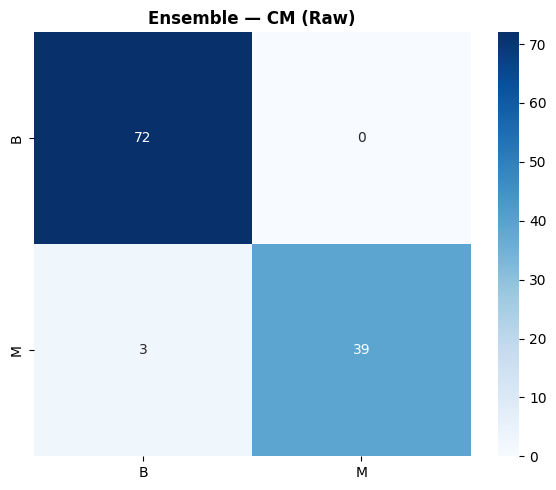

In [15]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['B','M'],yticklabels=['B','M'])
plt.title('Ensemble — CM (Raw)',fontweight='bold');plt.tight_layout();plt.show()

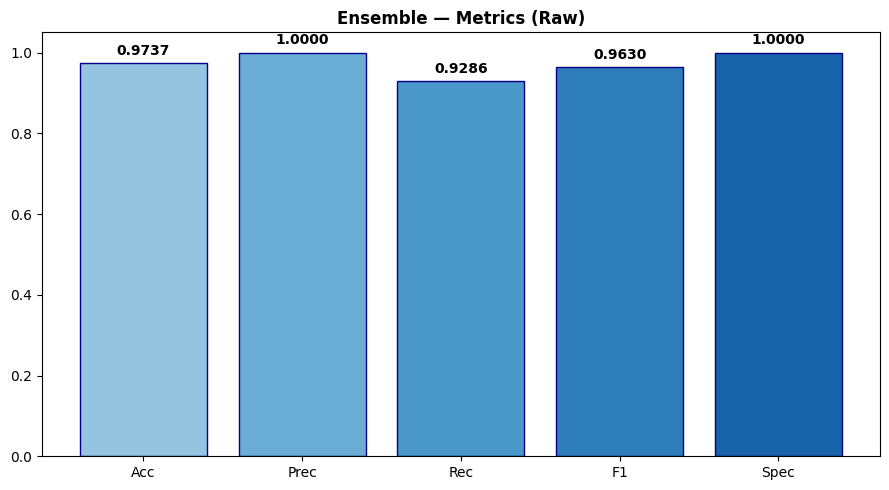

In [16]:
n=['Acc','Prec','Rec','F1','Spec'];v=[acc,prec,rec,f1,spec];c=plt.cm.Blues([0.4,0.5,0.6,0.7,0.8])
plt.figure(figsize=(9,5));bars=plt.bar(n,v,color=c,edgecolor='darkblue')
plt.ylim(0,1.05);plt.title('Ensemble — Metrics (Raw)',fontweight='bold')
for b,v in zip(bars,v):plt.text(b.get_x()+b.get_width()/2,b.get_height()+0.02,f'{v:.4f}',ha='center',fontweight='bold')
plt.tight_layout();plt.show()

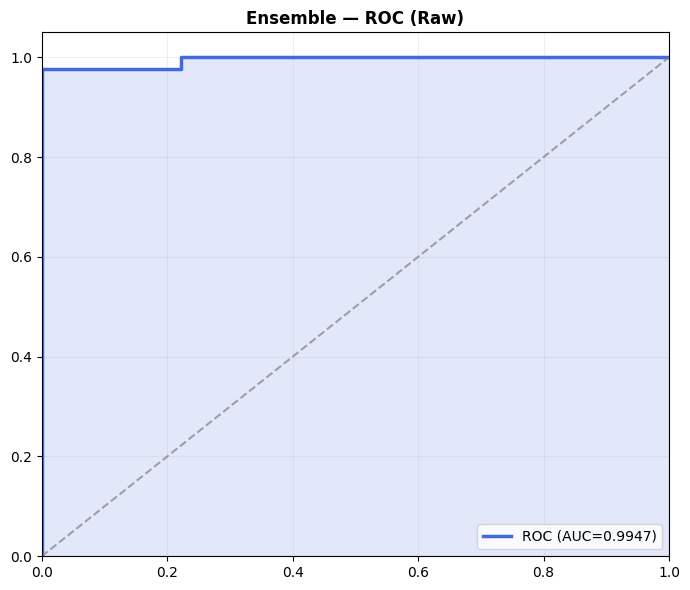

In [17]:
fpr,tpr,_=roc_curve(y_te,ypb)
plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,'royalblue',lw=2.5,label=f'ROC (AUC={auc:.4f})')
plt.fill_between(fpr,tpr,alpha=0.15,color='royalblue')
plt.plot([0,1],[0,1],'gray',ls='--',alpha=0.7)
plt.xlim(0,1);plt.ylim(0,1.05);plt.title('Ensemble — ROC (Raw)',fontweight='bold')
plt.legend();plt.grid(alpha=0.2);plt.tight_layout();plt.show()

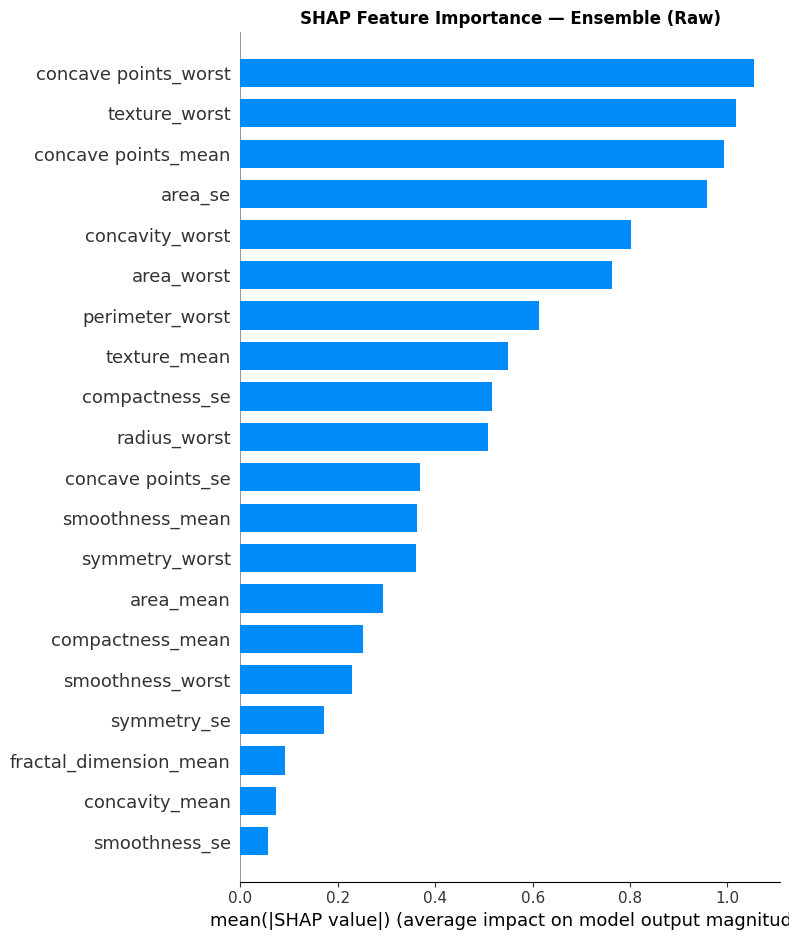

In [18]:
# SHAP explanation using XGBoost (the most interpretable base model)
xgb_model = ensemble.named_estimators_['xgb']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_te_s)

# Summary bar plot
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_te_s, feature_names=X.columns, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Ensemble (Raw)',fontweight='bold')
plt.tight_layout();plt.show()